# AM-Peak Trip Generation Rates per Person — by TAZ and Superzone

Assesses trips generated per person between 6:00 and 9:00 from the survey, using the `wf_new` household expansion weights on both sides of the ratio.

**Home zone definition: the zone where the person's `mainActivity` was Home at 3:00 AM** — the survey day starts at 03:00, and every person-day's first diary activity begins exactly then, so the home zone is the `taz` of that first activity when it is Home. The definition is applied per person per survey day; person-days whose 3:00 activity is not Home (3.4%) have no home zone that day and are excluded from both sides of the ratio.

- **Numerator** — expanded AM-peak trips (same extraction rule as all matrices) made that day by persons home in the zone at 3:00, attributed to that home zone regardless of where the trips occur.
- **Denominator** — expanded persons home in the zone at 3:00 (`wf_new` per person, summed).

This is a trip *production* rate by residence zone, computed per survey day and averaged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE = '#2a78d6', '#eb6834'
INK, INK2 = '#0b0b0b', '#52514e'

In [2]:
df = pd.read_csv('Input/Matrices/ACTIVITIES_DEC18_corrected.csv')
weights = pd.read_csv('Input/Matrices/households_with_weights.csv')[['HHID', 'wf_new']]
df = df.merge(weights, on='HHID', how='left', validate='many_to_one')
assert df['wf_new'].notna().all()

# home zone per person-day: taz of the first activity (starts 03:00) when it is Home
d = df.copy()
d['StartTime_dt'] = pd.to_datetime(d['StartTime'], dayfirst=True)
first = (d.sort_values(['INDIVID', 'ACT_DAY', 'ACT_ID'])
          .groupby(['INDIVID', 'ACT_DAY'])
          .first()
          .reset_index())
assert (first['StartTime_dt'].dt.strftime('%H:%M') == '03:00').all()

home = first[first['mainActivity'] == 'Home'][['INDIVID', 'ACT_DAY', 'taz', 'wf_new']].rename(columns={'taz': 'home_taz'})
home = home[home['ACT_DAY'].isin([10, 20])]  # drop the 86 stray records on residual days 11/22
excluded = len(first) - len(home)
print(f"person-days: {len(first):,} | Home at 3:00: {len(home):,} "
      f"| excluded (not Home at 3:00): {excluded:,} ({excluded / len(first):.1%})")

# superzone of the home taz via the keys table
keys = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
taz_to_sz = (keys[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int)
             .drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW'])
home['home_sz'] = home['home_taz'].map(taz_to_sz)
print(f"home taz outside the 778-zone system (no superzone): "
      f"{home['home_sz'].isna().sum()} person-days — kept in the TAZ table, absent from the SZ table")

person-days: 32,802 | Home at 3:00: 31,617 | excluded (not Home at 3:00): 1,185 (3.6%)
home taz outside the 778-zone system (no superzone): 130 person-days — kept in the TAZ table, absent from the SZ table


In [3]:
def am_peak_trips(df_day):
    d = df_day.sort_values(by=['INDIVID', 'tourID', 'ACT_ID'])
    d['origin'] = d.groupby(['INDIVID', 'tourID'])['taz'].shift(1)
    d['destination'] = d['taz']
    d['StartTime'] = pd.to_datetime(d['StartTime'], dayfirst=True)
    d['EndTime'] = pd.to_datetime(d['EndTime'], dayfirst=True)
    d['leaving_time'] = pd.to_datetime(np.where(d['mainActivity'] == 'Home', d['EndTime'], d['StartTime']))
    mask = (d['leaving_time'].dt.hour >= 6) & (d['leaving_time'].dt.hour < 9)
    f = d[mask].dropna(subset=['origin', 'destination'])
    # model-area trips only: both ends must have a real TAZ; Default arrival = no reported travel
    return f[(f['origin'] != 0) & (f['destination'] != 0) & (f['MODE_NAME'] != 'Default')]

# AM-peak trips per person-day, joined to that day's home zone
trips_pd = []
for day in (10, 20):
    t = am_peak_trips(df[df['ACT_DAY'] == day].copy())
    trips_pd.append(t.groupby('INDIVID').size().rename('n_trips').reset_index().assign(ACT_DAY=day))
trips_pd = pd.concat(trips_pd)

home = home.merge(trips_pd, on=['INDIVID', 'ACT_DAY'], how='left').fillna({'n_trips': 0})
home['w_trips'] = home['wf_new'] * home['n_trips']

for day in (10, 20):
    h = home[home['ACT_DAY'] == day]
    print(f"day {day}: expanded persons {h['wf_new'].sum():,.0f}, expanded AM trips {h['w_trips'].sum():,.0f}, "
          f"rate = {h['w_trips'].sum() / h['wf_new'].sum():.3f}")
day_rates = {day: home.loc[home['ACT_DAY'] == day, 'w_trips'].sum() / home.loc[home['ACT_DAY'] == day, 'wf_new'].sum()
             for day in (10, 20)}
overall_avg = np.mean(list(day_rates.values()))
print(f"overall AM-peak trips per person, avg of both days: {overall_avg:.3f}")

day 10: expanded persons 2,607,046, expanded AM trips 2,181,977, rate = 0.837
day 20: expanded persons 2,572,954, expanded AM trips 2,143,011, rate = 0.833
overall AM-peak trips per person, avg of both days: 0.835


In [4]:
def rates_by(col, data):
    parts = {}
    for day in (10, 20):
        h = data[data['ACT_DAY'] == day]
        g = h.groupby(col).agg(sampled_persons=('INDIVID', 'size'),
                               weighted_persons=('wf_new', 'sum'),
                               weighted_trips=('w_trips', 'sum'))
        g[f'rate_{day}'] = g['weighted_trips'] / g['weighted_persons']
        parts[day] = g.rename(columns={'sampled_persons': f'sampled_persons_{day}',
                                       'weighted_persons': f'weighted_persons_{day}',
                                       'weighted_trips': f'weighted_trips_{day}'})
    out = parts[10].join(parts[20], how='outer')
    out['rate_avg'] = out[['rate_10', 'rate_20']].mean(axis=1)
    return out

taz_rates = rates_by('home_taz', home)
sz_rates = rates_by('home_sz', home.dropna(subset=['home_sz']))

taz_rates.to_csv('Output/trip_generation_taz.csv', float_format='%.6g')
sz_rates.to_csv('Output/trip_generation_sz.csv', float_format='%.6g')
print(f"TAZ table: {len(taz_rates)} home zones | superzone table: {len(sz_rates)} zones")
print("saved: Output/trip_generation_taz.csv, Output/trip_generation_sz.csv")
sz_rates[['sampled_persons_10', 'weighted_persons_10', 'rate_10', 'rate_20', 'rate_avg']].round(3)

TAZ table: 520 home zones | superzone table: 35 zones
saved: Output/trip_generation_taz.csv, Output/trip_generation_sz.csv


,sampled_persons_10,weighted_persons_10,rate_10,rate_20,rate_avg
home_sz,,,,,
1.0,547,81064.624,0.861,0.910,0.885
2.0,725,128577.886,0.789,0.754,0.772
3.0,903,144165.199,0.801,0.808,0.805
4.0,1027,120679.908,0.597,0.633,0.615
5.0,262,41217.696,0.782,0.786,0.784
6.0,269,44033.302,0.904,0.928,0.916
7.0,295,42679.205,0.967,0.925,0.946
8.0,355,36130.123,0.890,0.935,0.913
9.0,363,60567.714,1.094,1.096,1.095


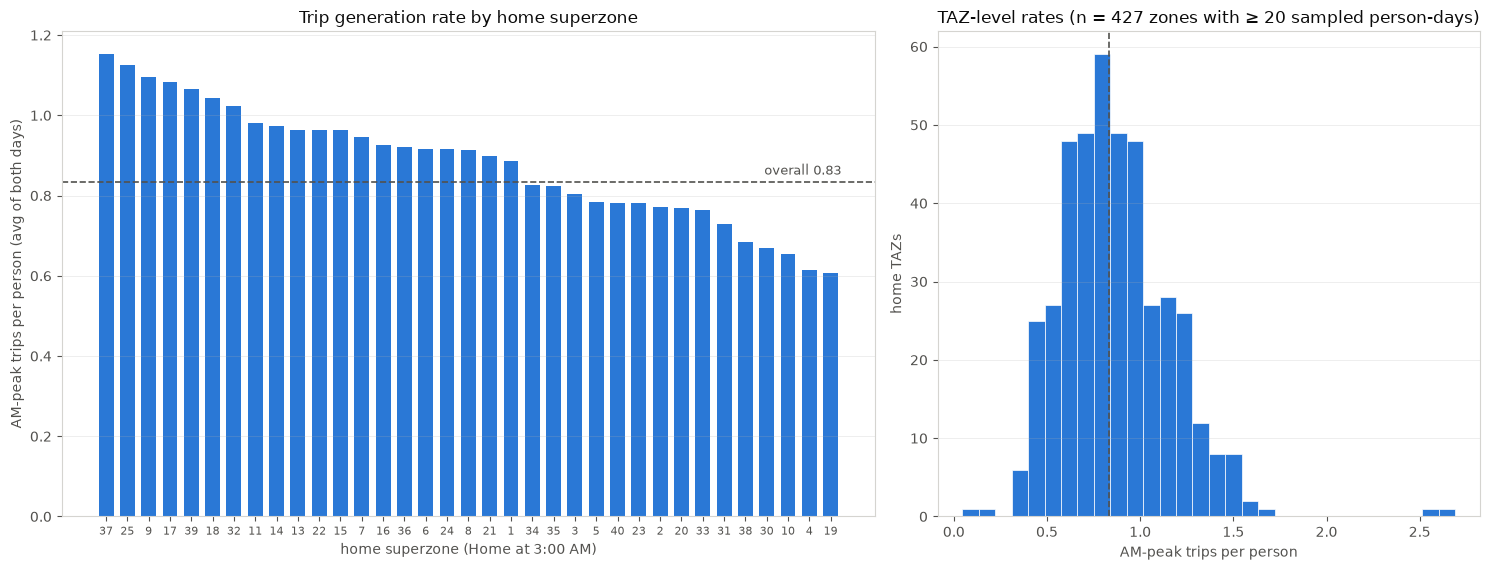

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), facecolor='white', gridspec_kw={'width_ratios': [1.5, 1]})

s = sz_rates.sort_values('rate_avg', ascending=False)
ax = axes[0]
ax.bar(range(len(s)), s['rate_avg'], color=BLUE, width=0.7)
ax.axhline(overall_avg, color=INK2, linestyle='--', linewidth=1.2)
ax.annotate(f'overall {overall_avg:.2f}', xy=(len(s) - 0.5, overall_avg), xytext=(0, 5),
            textcoords='offset points', color=INK2, fontsize=9, ha='right')
ax.set_xticks(range(len(s)))
ax.set_xticklabels([f'{int(z)}' for z in s.index], fontsize=8)
ax.set_xlabel('home superzone (Home at 3:00 AM)', color=INK2)
ax.set_ylabel('AM-peak trips per person (avg of both days)', color=INK2)
ax.set_title('Trip generation rate by home superzone', color=INK, fontsize=12)
ax.grid(True, axis='y', alpha=0.25, linewidth=0.6)
for sp in ax.spines.values(): sp.set_color('#d5d4d0')
ax.tick_params(colors=INK2)

ax = axes[1]
reliable = taz_rates[(taz_rates['sampled_persons_10'].fillna(0) + taz_rates['sampled_persons_20'].fillna(0)) >= 20]
ax.hist(reliable['rate_avg'], bins=30, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(overall_avg, color=INK2, linestyle='--', linewidth=1.2)
ax.set_xlabel('AM-peak trips per person', color=INK2)
ax.set_ylabel('home TAZs', color=INK2)
ax.set_title(f'TAZ-level rates (n = {len(reliable)} zones with ≥ 20 sampled person-days)', color=INK, fontsize=12)
ax.grid(True, axis='y', alpha=0.25, linewidth=0.6)
for sp in ax.spines.values(): sp.set_color('#d5d4d0')
ax.tick_params(colors=INK2)

plt.tight_layout()
plt.savefig('Output/figures/trip_generation_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print("superzone rates — highest and lowest (avg of both days):")
s = sz_rates.sort_values('rate_avg', ascending=False)
cols = ['sampled_persons_10', 'sampled_persons_20', 'rate_10', 'rate_20', 'rate_avg']
print(s[cols].head(5).round(3).to_string())
print("...")
print(s[cols].tail(5).round(3).to_string())

n_pd = taz_rates['sampled_persons_10'].fillna(0) + taz_rates['sampled_persons_20'].fillna(0)
print(f"\nTAZ reliability: {(n_pd < 20).sum()} of {len(taz_rates)} home TAZs have < 20 sampled "
      "person-days — treat their rates as indicative only.")

superzone rates — highest and lowest (avg of both days):
         sampled_persons_10  sampled_persons_20  rate_10  rate_20  rate_avg
home_sz                                                                    
37.0                    139                 134    1.169    1.135     1.152
25.0                     86                  85    1.035    1.216     1.125
9.0                     363                 358    1.094    1.096     1.095
17.0                    720                 704    1.095    1.072     1.083
39.0                    323                 321    1.098    1.031     1.065
...
         sampled_persons_10  sampled_persons_20  rate_10  rate_20  rate_avg
home_sz                                                                    
38.0                    499                 498    0.692    0.675     0.683
30.0                    340                 339    0.667    0.670     0.669
10.0                    416                 413    0.671    0.638     0.654
4.0                    1027

In [7]:
# Summary table: TAZ, SuperZone, trips per person, total population (wf_new x observed persons)
summary = pd.DataFrame({
    'TAZ': taz_rates.index.astype(int),
    'SuperZone': taz_rates.index.map(taz_to_sz).astype('Int64'),
    'trips_per_person': taz_rates['rate_avg'].round(3).values,
    'population': ((taz_rates['weighted_persons_10'].fillna(0) + taz_rates['weighted_persons_20'].fillna(0)) / 2).round(0).astype(int).values,
}).sort_values('TAZ')
summary.to_csv('Output/trip_generation_summary.csv', index=False)
print(f"saved: Output/trip_generation_summary.csv — {len(summary)} TAZ rows, "
      f"total population {summary['population'].sum():,}")
summary.head(10)

saved: Output/trip_generation_summary.csv — 520 TAZ rows, total population 2,590,000


,TAZ,SuperZone,trips_per_person,population
0,0,<NA>,0.000,34
1,101,1,1.069,5259
2,102,1,1.213,775
3,104,1,1.276,4203
4,105,<NA>,1.080,9286
5,106,1,1.264,6328
6,107,1,0.641,8087
7,108,1,0.816,7142
8,110,1,0.477,3888
9,111,1,0.553,4448


## Notes

- **Home = where `mainActivity` was Home at 3:00 AM**, per person per survey day (the survey day starts at 03:00 and every person-day's first activity begins exactly then). Individuals Home on both days sit in the same taz 99.99% of the time, so the per-day definition is stable in practice.
- Person-days not Home at 3:00 (3.4% — night workers, people away from home) are excluded from both numerator and denominator for that day, so rates describe persons who started the day at home.
- Only model-area trips count (both ends with a real TAZ ≠ 0, Default-mode arrivals excluded). Home zones outside the 778 system appear in the TAZ table but not the superzone table.
- This diary-based definition agrees with the household register (`households_with_weights.csv` TAZ) for ~95% of households; disagreements are almost all adjacent zones.